## Preliminaries

### Import statements

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

### Global values

In [2]:
DATA_DIR = "data"

### Load tokens

In [3]:
token_file = os.path.join(DATA_DIR, "tokens.tsv")
tokens = pd.read_csv(token_file, delimiter="\t", dtype=str)

### Remove punctuation

I assume punctuation is tied to the edition used by Perseus and might introduce an extra signal. Consider changing this later.

In [4]:
tokens = tokens.loc[~(tokens["pos"]=="PUNCT")]

### Preprocess lemmas

#### Some bespoke corrections

In [6]:
# correct elisions and accents
for corr_file in ["accent_corrections.tsv", "lemma_corrections.tsv"]:
    with open(os.path.join(DATA_DIR, corr_file)) as f:
        for row in f.readlines():
            if not row.startswith("#"):
                old, new = row.strip().split("\t")
                tokens.loc[tokens["lemma"]==old, "lemma"] = new

#### Select most frequent lemmas

In [7]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens["lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas])

lemma
καί        13671
δʼ         11523
δέ          9816
ὁ           9589
τε          4038
           ...  
ἑταῖρος      560
ὅσος         546
αἱρέω        546
σφεῖς        545
κόρη         535
Name: count, Length: 100, dtype: int64

### Preprocess POS tags
#### Select all tags

In [8]:
# get corpus-wide POS counts
corpus_pos_count = tokens["pos"].value_counts()
display(corpus_pos_count)

# select all
all_pos = corpus_pos_count.index

pos
NOUN     122396
VERB      82098
ADJ       68072
PART      43638
ADV       33412
ADP       25819
PRON      25287
CCONJ     18309
SCONJ      4504
AUX        3489
DET        1588
INTJ        614
NUM         485
X            57
PROPN         6
Name: count, dtype: int64

### Preprocess morphological features
#### Consolidate all morphs into one column
Note: assumes there are no value collisions across morph columns, which is true for this data.

In [9]:
# melt morph column values
morph = tokens.melt(
        value_vars=["verbform", "mood", "tense", "voice", "person", "number", "case", "gender"],
        ignore_index = False,
    ).dropna()

# agg as list, add to token table
tokens["morph"] = morph.groupby(morph.index).agg(morph = ("value", list))

#### Rank morph features and select all

In [10]:
# get corpus wide morph counts
corpus_morph_count = tokens["morph"].explode().value_counts()
display(corpus_morph_count)

# select all but anomalously low
top_morph = corpus_morph_count[corpus_morph_count > 1000].index

morph
Sing        219647
Masc        133310
Acc          79926
Plur         75943
Nom          74252
Fem          64224
Act          59682
Fin          54853
Past         52041
Ind          46386
3            43396
Neut         42976
Gen          42714
Dat          42265
Pres         29354
Part         25061
Mid          23631
2             5859
Inf           5680
1             5678
Sub           3263
Voc           3120
Fut           3003
Imp           2952
Opt           2252
Pass          2204
Dual          1510
Pqp           1190
Fem;Masc         1
Name: count, dtype: int64

## Training samples

Here we divide all the tokens into groups by author and narrative/speech. There's a special group just for Odysseus' apologue. From these groups, we then generate samples of `sample_size` random tokens without replacement. We'll use these samples to train a simple model to discriminate speech from narrative.

In [11]:
def run_training(feature_set, sample_size=1000, seed=1):
    # Narratological groups
    nr_mask = tokens["speaker"].isna()
    sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

    # default group is "other"
    nara_group_ids = pd.Series("oth", index=tokens.index)
    nara_group_ids[nr_mask] = "nar"
    nara_group_ids[sp_mask] = "spk"

    # Authorship groups
    auth_group_ids = tokens["work"].str.slice(0,4)

    # Combined two-factor group
    group_ids = auth_group_ids + "-" + nara_group_ids

    # Initialize random number generator
    rng = np.random.default_rng(seed)

    # Sample labels
    sample_ids = pd.Series(index=tokens.index)
    for group in group_ids.unique():
        n_toks = sum(group_ids==group)
        sample_ids.loc[group_ids==group] = rng.permutation(n_toks) // sample_size
    sample_ids = group_ids + "-" + sample_ids.map(lambda f: f"{int(f):03d}")

    # Calculate sample sizes
    tokens_per_sample = tokens.groupby(sample_ids).size()

    # use a different scaler for each feat class
    scalers = {}

    # collect output vectors for each feat class
    parts = []

    for col, features in feature_set.items():

        # Generate feature tallies
        raw = (tokens[col]
            .explode()
            .where(lambda x: x.isin(features))
            .pipe(pd.get_dummies)
            .groupby(level=0).agg("sum")
            .groupby(sample_ids).agg("sum")
        )
        
        # normalize as freq / 1000 words
        normalized = raw.div(tokens_per_sample, axis=0) * 1000

        # scale
        scaler = StandardScaler()
        scaled = pd.DataFrame(
            data = scaler.fit_transform(normalized),
            columns = [f"{col}_{f}" for f in features],
            index = normalized.index,
        )
        scalers[col] = scaler
        parts.append(scaled)

    # combine all vectors into one table
    composite = pd.concat(parts, axis=1)
    
    # principal components analysis
    pca_model = PCA(n_components=3)

    pca = pd.DataFrame(
        data = pca_model.fit_transform(composite),
        columns = ["PC1", "PC2", "PC3"],
        index = composite.index,
    )

    # logistic regression on nar/spk only
    mask = ~pca.index.str.contains("-oth-")
    X = pca.loc[mask, ["PC1", "PC2"]].values
    y = pca.index[mask].str.contains("spk").astype(int)
    clf = LogisticRegression()
    clf.fit(X, y)

    # used for labeling PCA graphs
    nara_label = nara_group_ids.groupby(sample_ids).agg("first").values
    auth_label = auth_group_ids.groupby(sample_ids).agg("first").values

    # difference of z-scores
    diff = (
            composite.loc[nara_label=="spk"].agg("mean") -
            composite.loc[nara_label=="nar"].agg("mean")
        ).sort_values()
 
    # bundle outputs
    return dict(
        feature_set = feature_set,
        sample_size = sample_size,
        seed = seed,
        nara_label = nara_label,
        auth_label = auth_label,
        scalers = scalers,
        pca_model = pca_model,
        scaled = scaled,
        pca = pca,
        clf = clf,
        diff = diff,
    )

#### run training

In [12]:
feature_set = {
    "lemma": top_lemmas,
    "pos": all_pos,
    "morph": top_morph,
}

train = run_training(feature_set)

### Plot

In [13]:
def plot_training(training):
    # plot first two principal components

    g = sns.relplot(data=training["pca"],
        x = "PC1",
        y = "PC2",
        hue = training["auth_label"],
        style = training["nara_label"],
    )

    # add decision boundary
    
    # get the axis for the existing plot
    ax = g.ax
    xlim = ax.get_xlim()

    # solve for y at each x endpoint: coef[0]*x + coef[1]*y + intercept = 0
    #   => y = -(coef[0]*x + intercept) / coef[1]
    w = training["clf"].coef_[0]
    b = training["clf"].intercept_[0]
    xs = np.array(xlim)
    ys = -(w[0] * xs + b) / w[1]
    
    ax.plot(xs, ys, "k--", linewidth=1)
    ax.set_xlim(xlim)  # restore limits so the line doesn't expand the plot
    
    plt.show()

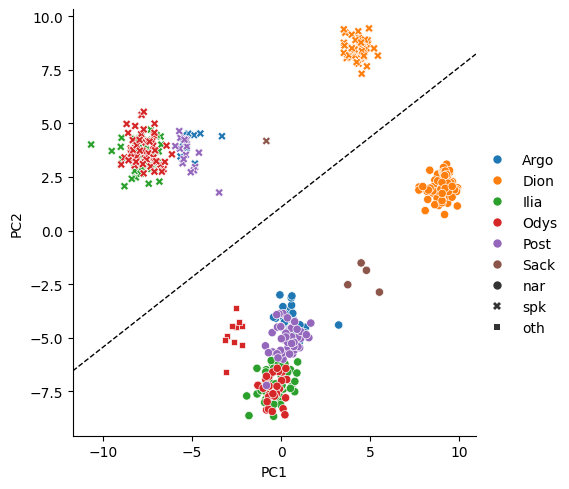

In [14]:
plot_training(train)

## Calculate rolling samples

In [15]:
def rolling_samples(training, window_size=500, min_ratio=0.7):

    # how many tokens in each sample
    tokens_per_sample = (
        tokens["lemma"]
        .rolling(window=window_size, center=True,
                 min_periods=int(window_size * min_ratio))
        .agg("count")
        .fillna(0)
        .astype(int)
    )

    # calculate one normalized, scaled feature vector per col
    parts = []
    for col, features in training["feature_set"].items():

        # raw count per sample
        raw = (tokens[col]
            .explode()
            .where(lambda x: x.isin(features))
            .pipe(pd.get_dummies)
            .groupby(level=0).agg("sum")
            .rolling(window=window_size, center=True, min_periods=int(window_size * 0.7))
            .agg("sum")
            .fillna(0)
            .astype(int)
        )

        # normalize by 1000 tokens
        normalized = raw.div(tokens_per_sample, axis=0) * 1000

        # scaled
        scaled = pd.DataFrame(
            data = training["scalers"][col].transform(normalized),
            columns = [f"{col}_{f}" for f in features],
            index = raw.index,
        )
        
        parts.append(scaled)

    # combine all vectors in one table
    composite = pd.concat(parts, axis=1)

    # remove NaN rows
    valid = composite.dropna()

    # transform vectors using pre-fitted pca model
    pca = pd.DataFrame(
        data = training["pca_model"].transform(valid),
        columns = ["PC1", "PC2", "PC3"],
        index = valid.index,
    )
    
    # calculate speechiness score
    X = pca[["PC1", "PC2"]].values
    proj = X @ training["clf"].coef_.T + training["clf"].intercept_
    
    speech_score = pd.DataFrame(dict(
            work = tokens.loc[pca.index, "work"],
            pref = tokens.loc[pca.index, "pref"],
            line = tokens.loc[pca.index, "line"],
            speech_id = tokens.loc[pca.index, "speech_id"],
            score = proj.flatten(), 
        ),
        index = pca.index)

    return dict(
        window_size = window_size,
        min_ratio = min_ratio,
        speech_score = speech_score,
    )

In [16]:
test = rolling_samples(train)

### Plot speech score by verse line

In [17]:
def plot_rolling(data, work, pref):
    mask = (data["speech_score"]["work"] == work) & (data["speech_score"]["pref"] == pref)

    g = sns.relplot(
        x = data["speech_score"][mask].index,
        y = data["speech_score"][mask].score,
        kind = "line",
    )
    g.set(
        title = work + " " + pref,
        xlabel = "line",
    )
    g.figure.set_size_inches(8, 4)

    # set x-tics
    xmin = data["speech_score"][mask].index.min()
    xmax = data["speech_score"][mask].index.max()
    ymin = data["speech_score"]["score"].min()
    ymax = data["speech_score"]["score"].max()

    x_ticks = []
    x_tick_labels = []
    for idx in data["speech_score"][mask].index:
        ln = data["speech_score"].loc[idx, "line"]
        if int(ln) % 50 == 0:
            if ln not in x_tick_labels:
                x_ticks.append(idx)
                x_tick_labels.append(ln)
    g.ax.plot([xmin,xmax], [0,0], "k--", lw=1)
    g.set(
        xticks = x_ticks,
        xticklabels = x_tick_labels,
        xlim = (xmin, xmax),
        ylim = (ymin, ymax),
    )

    speech_data = data["speech_score"].dropna(subset=["speech_id"])
    for sid, group in speech_data.groupby("speech_id"):
        g.ax.axvspan(group.index.min(), group.index.max(), alpha=0.15, color="gray", linewidth=0)

    plt.show()

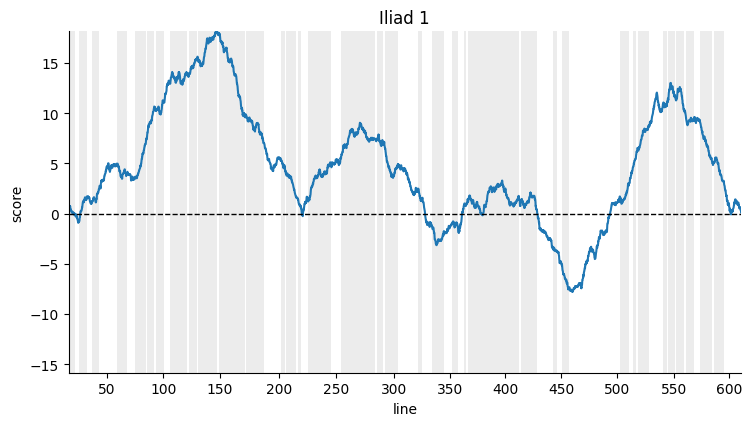

In [18]:
plot_rolling(data=test, work="Iliad", pref="1")

## Exploring feature significance

In [21]:
train["diff"].head(20)

morph_Acc      -1.783652
morph_Voc      -1.730783
morph_2        -1.548609
lemma_εἰμί     -1.397958
morph_Imp      -1.370200
morph_Gen      -1.341189
morph_1        -1.255655
lemma_ὡς       -1.179538
lemma_μή       -0.987075
lemma_ἐπʼ      -0.974146
lemma_κόρη     -0.952555
lemma_ἀχαιός   -0.922820
morph_Sub      -0.906240
lemma_μῦθος    -0.876321
lemma_γαῖα     -0.850839
lemma_τρώς     -0.830164
pos_CCONJ      -0.802935
lemma_ὅς       -0.779997
lemma_ἔπος     -0.767273
pos_X          -0.765017
dtype: float64